In [798]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(corrplot)
library(ggrepel)


theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [803]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

In [817]:
delta_chromatin = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")
lfc_isoforms = read.table(file = "../data/7_mature_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")
# lfc_isoforms = read.table(file = "../data/7_nascent_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")

shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))

chrom_cols <- c("promoter-accessible", "intragenic-accessible",
                "co-accessible", "fully-nucleosomal", "fully-accessible")
iso_cols   <- c("lfc_canonical", "lfc_downstream", "lfc_antisense")

df <- cbind(delta_chromatin[shared_genes, chrom_cols], lfc_isoforms[shared_genes,iso_cols])

df[is.na(df)] = 0


df_scaled <- df %>% mutate(across(all_of(c(chrom_cols, iso_cols)), scale))

cor_mat <- cor(
    df_scaled %>%  dplyr::select(chrom_cols),
    df_scaled %>%  dplyr::select(iso_cols),
    use = "pairwise.complete.obs",
)
range(cor_mat)

[1] -0.1518677  0.1635554

pdf 
  2

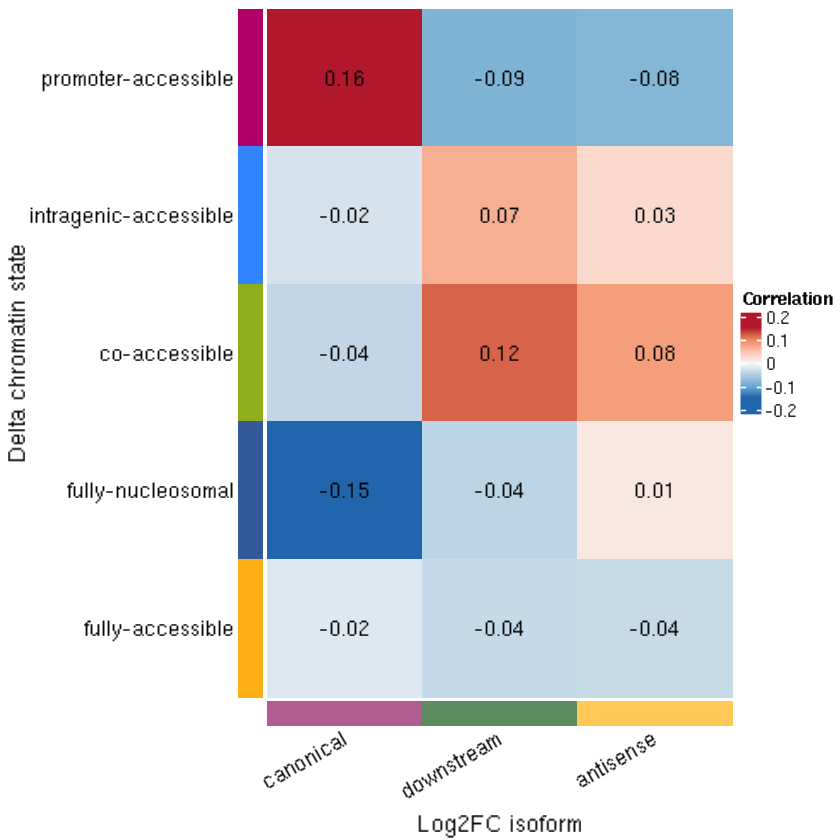

In [819]:
chrom_col <- polychrome()[c(7, 10, 8, 6, 15)]
names(chrom_col) <- c("fully-accessible", "co-accessible", "promoter-accessible",
                     "intragenic-accessible", "fully-nucleosomal")
mcolors = mcolors[chrom_level]

iso_level = c("canonical", "downstream", "antisense")
colnames(cor_mat)<- iso_level
iso_col <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
names(iso_col) <- iso_level

row_ha <- rowAnnotation(
  State = chrom_level,
  col   = list(State = chrom_col),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

col_ha <- HeatmapAnnotation(
  State = iso_level,
  col   = list(State = iso_col),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

ht <- Heatmap(cor_mat,
        name = "Correlation",
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        col = colorRamp2(c(-0.15, -0.1, 0, 0.1, 0.15), c("#2166ac", "#67a9cf", "#f7f7f7", "#ef8a62", "#b2182b")),
        row_title = "Delta chromatin state",
        column_title = "Log2FC isoform",
        column_title_side = "bottom",
        column_names_rot = 30,
        show_row_dend = FALSE,
        show_column_dend = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        column_names_side = "bottom",
        row_names_side = "left",
        left_annotation = row_ha,
        top_annotation = NULL,
        bottom_annotation = col_ha,
        cell_fun = function(j, i, x, y, w, h, fill) {
          grid.text(sprintf("%.2f", cor_mat[i, j]), x, y, gp = gpar(fontsize = 12))
        })

draw(ht)

# lgd_chrom <- Legend(
#   title     = "Chromatin state",
#   labels    = names(chrom_col),
#   legend_gp = gpar(fill = chrom_col)
# )

pdf('../figures/Supp_pearson_correlation_delta_chromain_and_Log2FC_isoform.pdf', width = 5, height = 4)
draw(ht,      
     column_title = "Pearson correlation\nDelta chromatin states vs Log2FC isoform",
     column_title_gp = gpar(fontsize = 12),
     heatmap_legend_side = "right")
dev.off()

draw(ht, heatmap_legend_side = "right")

In [480]:
df_complete <- df_scaled %>% drop_na(all_of(c(chrom_cols, iso_cols)))

X_chrom <- df_complete %>% dplyr::select(all_of(chrom_cols)) %>% as.matrix()
Y_iso   <- df_complete %>% dplyr::select(all_of(iso_cols))   %>% as.matrix()

cca_fit <- cc(X_chrom, Y_iso)
cca_fit$cor

ERROR: Error in chol.default(Bmat): the leading minor of order 5 is not positive definite


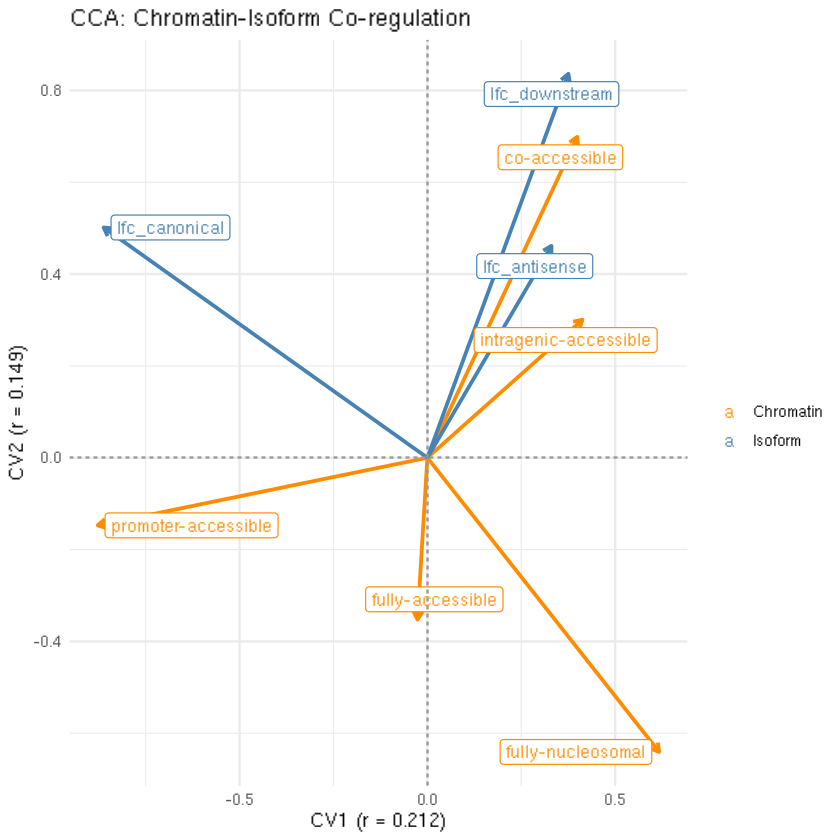

In [820]:
# Chromatin loadings on each canonical variate
chrom_loadings <- as.data.frame(cca_fit$scores$corr.X.xscores)
chrom_loadings$chromatin <- chrom_cols

# Isoform loadings
iso_loadings <- as.data.frame(cca_fit$scores$corr.Y.yscores)
iso_loadings$isoform <- iso_cols



load_df <- bind_rows(
  chrom_loadings %>%
    dplyr::select(name = chromatin, CV1 = V1, CV2 = V2) %>%
    dplyr::mutate(type = "Chromatin"),
  iso_loadings %>%
    dplyr::select(name = isoform, CV1 = V1, CV2 = V2) %>%
    dplyr::mutate(type = "Isoform")
)

ggplot(load_df, aes(x = CV1, y = CV2, color = type, label = name)) +
  geom_segment(aes(xend = 0, yend = 0), arrow = arrow(ends = "first", length = unit(0.2, "cm")),
               linewidth = 0.8) +
  geom_label_repel(size = 3.5, max.overlaps = 20) +
  scale_color_manual(values = c("Chromatin" = "darkorange", "Isoform" = "steelblue")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey60") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey60") +
  labs(x = paste0("CV1 (r = ", round(cca_fit$cor[1], 3), ")"),
       y = paste0("CV2 (r = ", round(cca_fit$cor[2], 3), ")"),
       title = "CCA: Chromatin-Isoform Co-regulation",
       color = "") +
  theme_minimal()

set.seed(42)
n_perm <- 999
perm_cors <- replicate(n_perm, {
  Y_perm <- Y_iso[sample(nrow(Y_iso)), ]
  cc(X_chrom, Y_perm)$cor[1]
})

# p-value
mean(perm_cors >= cca_fit$cor[1])

## find overlaps between isoform change and chromatin change

In [821]:
delta_chromatin = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")
lfc_isoforms = read.table(file = "../data/7_mature_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")

In [822]:
counts = read.table(file = "../data/7_mature_rna_tss_count.tsv", sep = "\t", header = TRUE, row.names = 1, check.names = FALSE)
counts_long<- counts %>% 
    mutate(iso_id = rownames(.) %>% str_split_i(pattern = "_", 1)) %>%
    mutate(feature_id = str_split_i(iso_id, pattern = ":", 2), gene_id = str_split_i(iso_id, pattern = ":", 1)) %>% 
    pivot_longer(colnames(counts), names_to = "sample", values_to = "count")

gene_totals <- counts_long %>%
    group_by(gene_id, sample) %>%
    summarise(total = sum(count), .groups = "drop")

iso_usage <- counts_long %>%
    left_join(gene_totals, by = c("gene_id", "sample")) %>%
    mutate(usage = if_else(total > 0, count / total, NA_real_)) %>% 
    dplyr::select(iso_id, feature_id, gene_id, sample, usage) %>%
    pivot_wider(names_from = sample, values_from = usage)

df1<- iso_usage %>%
    mutate(WT_mean = rowMeans(across(c('WT rep1', 'WT rep2', 'WT rep3'))),
          MUT_mean = rowMeans(across(c('MUT rep1', 'MUT rep2', 'MUT rep3'))),
          feature_id = str_split_i(iso_id, ':', 2),
          gene_id = str_split_i(iso_id, ':', 1)
          ) %>% 
    dplyr::select(WT_mean, MUT_mean, feature_id, gene_id) %>% 
    pivot_wider(names_from = feature_id, values_from = c(WT_mean, MUT_mean)) %>% 
    column_to_rownames("gene_id")


chrom_usage<- read.table("../data/supp/260313_diff_nuc_promoter_restricted_usages_table.tsv", sep = "\t", header = TRUE, row.names = 1)

df2<- chrom_usage %>%
    mutate(WT_mean = rowMeans(across(c('WT_rep1', 'WT_rep2'))),
          MUT_mean = rowMeans(across(c('MUT_rep1', 'MUT_rep2'))),
          chrom_state = str_split_i(rownames(.), ':', 2),
          geneid = str_split_i(rownames(.), ':', 1)
          ) %>% 
    dplyr::select(WT_mean, MUT_mean, chrom_state, geneid) %>% 
    pivot_wider(names_from = chrom_state, values_from = c(WT_mean, MUT_mean)) %>% 
    column_to_rownames("geneid")


shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')
iso_cols   <- c("lfc_canonical", "lfc_downstream", "lfc_antisense")
df <- cbind(delta_chromatin[shared_genes,], lfc_isoforms[shared_genes,iso_cols])
df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

df<- cbind(df, df2[rownames(df), ])
df<- cbind(df, df1[rownames(df), ])

df[is.na(df)] = 0

dominance_threshold = 0.3
WT_usage = 0
MUT_usage = 0
mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

,promoter-accessible,intragenic-accessible,co-accessible,fully-nucleosomal,fully-accessible,class,lfc_canonical,lfc_downstream,lfc_antisense,WT_mean_co-accessible,⋯,WT_mean_downstream,MUT_mean_antisense,MUT_mean_canonical,MUT_mean_downstream,shift_score,shift_score_iso,total_abs_change,target_abs_change,dominance,geneid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
YOR214C,0.1149028,0.167657542,0.23330181,-0.5306261,0.01476398,low,4.6678557,0.000000,0.0000000,0.10719180,⋯,0.00000000,0.09666667,0.81142857,0.09190476,0.6455288,4.6678557,1.0612522,0.6455288,0.6082709,YOR214C
YGR259C,0.1212467,0.050601862,0.18269972,-0.3956717,0.04112343,low,2.7727730,0.000000,0.0000000,0.04877062,⋯,0.00000000,0.00000000,0.94257795,0.05742205,0.5169183,2.7727730,0.7913433,0.5169183,0.6532163,YGR259C
YTP1,0.3083023,0.008029803,0.08116731,-0.4274381,0.02993875,low,1.8424657,2.028394,1.3655145,0.09169051,⋯,0.23433048,0.48836134,0.21032103,0.30131763,0.7357404,3.8708594,0.8548762,0.7357404,0.8606396,YTP1
SPO19,0.3151887,0.019732957,0.10834813,-0.4723841,0.02911432,low,1.5526486,0.000000,0.0000000,0.02002861,⋯,0.00000000,0.07539683,0.89682540,0.02777778,0.7875728,1.5526486,0.9447683,0.7875728,0.8336148,SPO19
YKL065W-A,0.2756598,0.012201662,-0.02986704,-0.2798434,0.02184902,low,0.5768444,0.000000,0.0000000,0.06784961,⋯,0.53636364,0.04766000,0.65392433,0.29841568,0.5555032,0.5768444,0.6194209,0.5555032,0.8968105,YKL065W-A
DIA4,0.1422617,0.074724378,0.10554916,-0.3872265,0.06469123,low,0.5218640,0.000000,0.6101884,0.07305696,⋯,0.00000000,0.34470020,0.56859335,0.08670645,0.5294882,0.5218640,0.7744530,0.5294882,0.6836932,DIA4
RAD17,0.1231917,0.185146780,0.12362966,-0.4735097,0.04154153,low,0.5087119,0.000000,0.4708360,0.05357143,⋯,0.07092581,0.55168291,0.36252112,0.08579597,0.5967015,0.5087119,0.9470195,0.5967015,0.6300837,RAD17
ZIP2,0.2387147,0.037924364,0.09631522,-0.4167270,0.04377275,low,0.0000000,2.971615,0.4099091,0.07523773,⋯,0.08333333,0.49011544,0.04343434,0.46645022,0.6554417,2.9716154,0.8334540,0.6554417,0.7864161,ZIP2
IDP3,0.2400095,0.025369876,0.07520002,-0.3903339,0.04975451,low,0.0000000,1.001976,1.4641033,0.10221629,⋯,0.56137566,0.33105783,0.09471084,0.57423132,0.6303434,1.0019756,0.7806679,0.6303434,0.8074413,IDP3


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


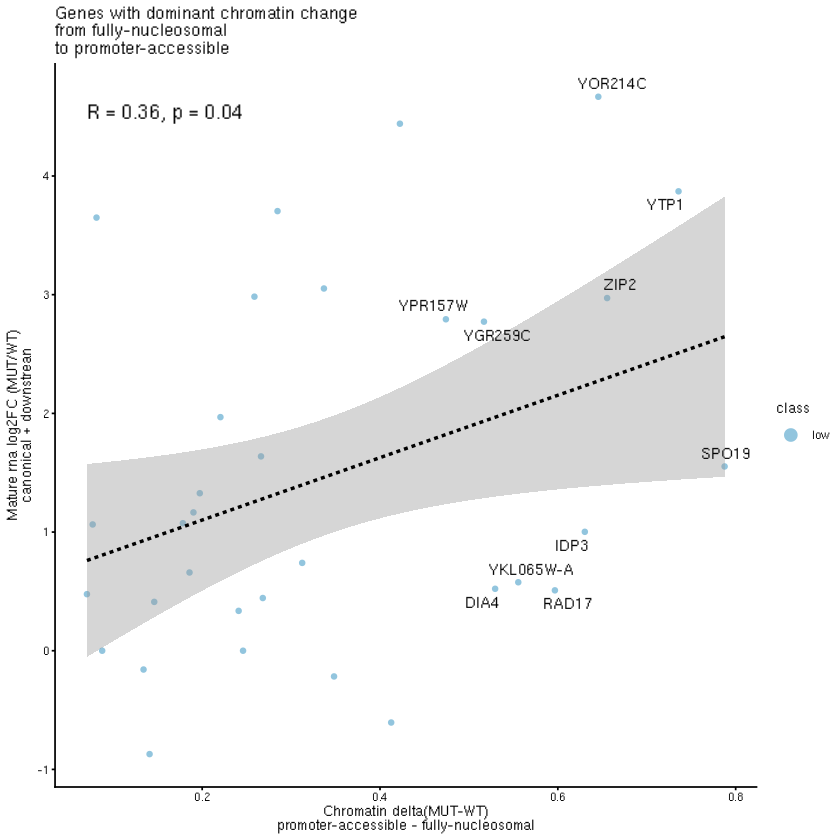

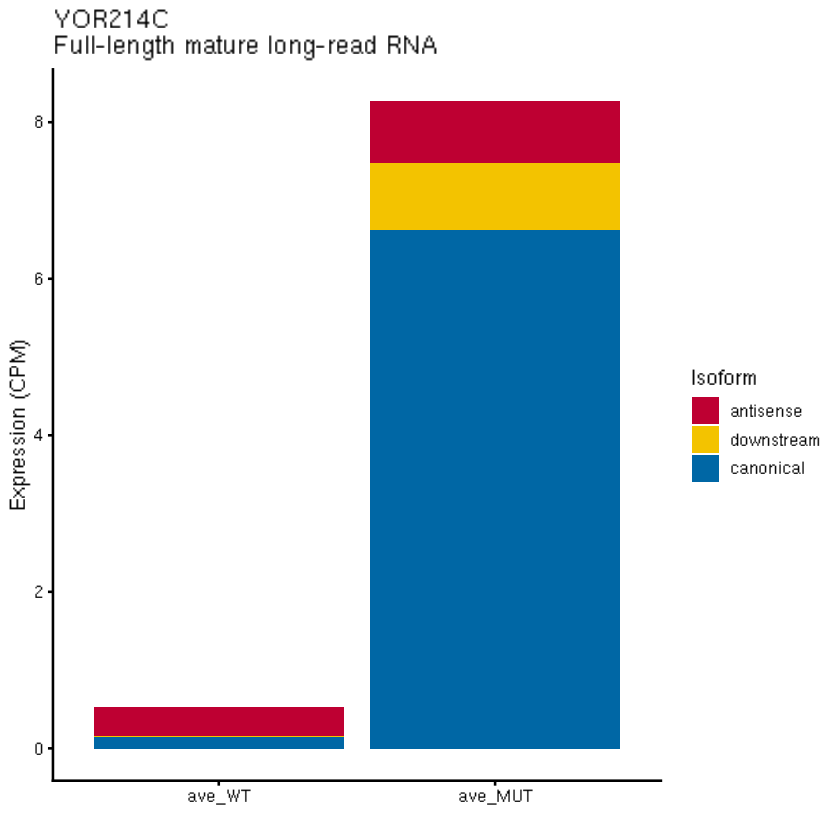

In [823]:
down_state = c('fully-nucleosomal')
up_state = c('promoter-accessible')

candidates <- df %>%
    filter(
        if_all(all_of(WT_state),  ~ .x > WT_usage),
        if_all(all_of(MUT_state),  ~ .x > MUT_usage),
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_canonical + lfc_downstream, 
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'low')

top_3<- candidates %>% head(n = 10) %>% arrange(-lfc_canonical)
top_3
candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_point(aes(color = class), size = 1) +
    labs(x = 'Chromatin delta(MUT-WT)\npromoter-accessible - fully-nucleosomal', 
         y = 'Mature rna log2FC (MUT/WT)\ncanonical + downstrean',
         title = 'Genes with dominant chromatin change\nfrom fully-nucleosomal\nto promoter-accessible') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    theme_classic(base_size=8) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = top_3,
        aes(label = geneid),
        size = 3, max.overlaps = 12
    ) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave('../figures/Supp_correlation_chromain_isoform_fully-nucleosomal_down_promoter_accessible_up.pdf', width = 4, height = 3)

plot_expr_telo(tpm, "YOR214C")
ggsave('../figures/Supp_YOR214C_cpm.pdf', width = 4, height = 3.5)

,promoter-accessible,intragenic-accessible,co-accessible,fully-nucleosomal,fully-accessible,class,lfc_canonical,lfc_downstream,lfc_antisense,WT_mean_co-accessible,⋯,WT_mean_downstream,MUT_mean_antisense,MUT_mean_canonical,MUT_mean_downstream,shift_score,shift_score_iso,total_abs_change,target_abs_change,dominance,geneid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
UBX7,-0.7746342,0.04402234,0.07867738,0.5713252,0.08060924,medium,-1.5696877,0.000000,0.00000,0.06628202,⋯,0.02560054,0.06316099,0.8249042,0.1119348,0.8186565,1.569688,1.549268,0.8186565,0.5284149,UBX7
YGL039W,-0.5642901,0.23942032,0.16490123,0.1384313,0.02153725,medium,-0.9214197,1.854035,0.00000,0.13126518,⋯,0.03208341,0.02627004,0.7890727,0.1846573,0.8037104,2.775455,1.128580,0.8037104,0.7121430,YGL039W
FMS1,-0.7075485,0.15068068,0.51231168,0.0000000,0.04455609,medium,-0.6948407,1.904422,1.65563,0.10441635,⋯,0.13043478,0.34127171,0.3324003,0.3263280,0.8582291,4.254892,1.415097,0.8582291,0.6064808,FMS1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


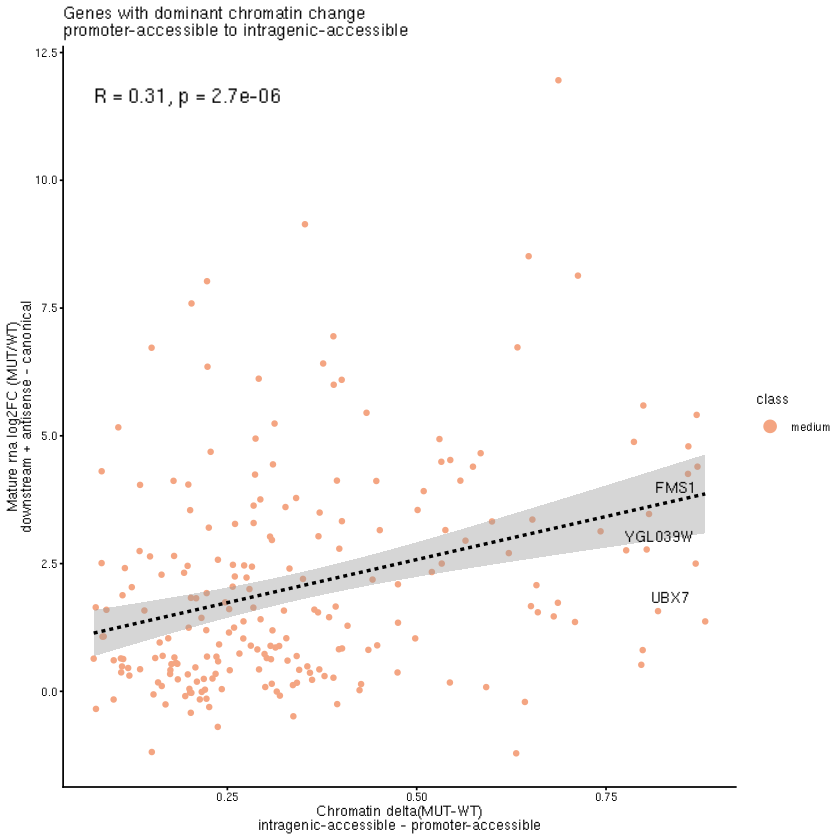

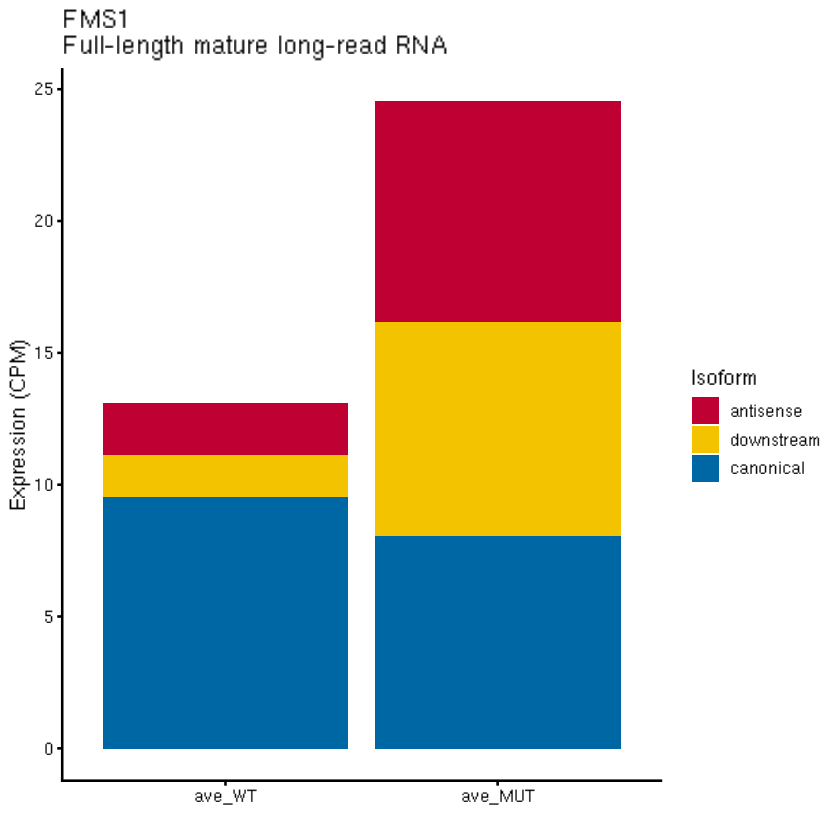

In [824]:
down_state = c('promoter-accessible')
up_state = c('intragenic-accessible')
WT_state = paste0('WT_mean_', down_state)
MUT_state = paste0('MUT_mean_', up_state)

candidates <- df %>%
    filter(
        if_all(all_of(WT_state),  ~ .x > WT_usage),
        if_all(all_of(MUT_state),  ~ .x > MUT_usage),
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_downstream + lfc_antisense - lfc_canonical,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold)  %>% filter(class == 'medium')

top_3<- candidates %>% head(n = 10) %>% arrange(lfc_canonical) %>% head(3)
top_3
candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_point(aes(color = class), size = 1) +
    labs(x = 'Chromatin delta(MUT-WT)\nintragenic-accessible - promoter-accessible', 
         y = 'Mature rna log2FC (MUT/WT)\ndownstream + antisense - canonical',
         title = 'Genes with dominant chromatin change\npromoter-accessible to intragenic-accessible') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    theme_classic(base_size=8) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = top_3,
        aes(label = geneid),
        size = 3, max.overlaps = 12
    ) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave('../figures/Supp_correlation_chromain_isoform_promoter_accessible_down_intragenic_accessible_up.pdf', width = 4, height = 3)

plot_expr_telo(tpm, "FMS1")
ggsave('../figures/Supp_FMS1_cpm.pdf', width = 4, height = 3.5)

,promoter-accessible,intragenic-accessible,co-accessible,fully-nucleosomal,fully-accessible,class,lfc_canonical,lfc_downstream,lfc_antisense,WT_mean_co-accessible,⋯,WT_mean_downstream,MUT_mean_antisense,MUT_mean_canonical,MUT_mean_downstream,shift_score,shift_score_iso,total_abs_change,target_abs_change,dominance,geneid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
FPR3,-0.4600456,0.07937216,0.12020409,0.2184800,0.041989436,high,-1.256339,-1.1262814,2.07925,0.1333496,⋯,0.05467135,0.017547464,0.9246194,0.05783318,0.6785256,1.256339,0.9200913,0.6785256,0.7374547,FPR3
ZWF1,-0.6109334,0.00000000,0.35227396,0.1700578,0.088601701,high,-1.051497,0.2490849,0.00000,0.3215542,⋯,0.03061078,0.016263294,0.9073271,0.07640963,0.7809912,1.051497,1.2218669,0.7809912,0.6391786,ZWF1
GPI16,-0.8026296,0.00000000,0.07206447,0.7239237,0.006641395,high,-1.029033,2.7620472,0.00000,0.1247685,⋯,0.06050535,0.009147026,0.5217339,0.46911905,1.5265534,1.029033,1.6052592,1.5265534,0.9509700,GPI16


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


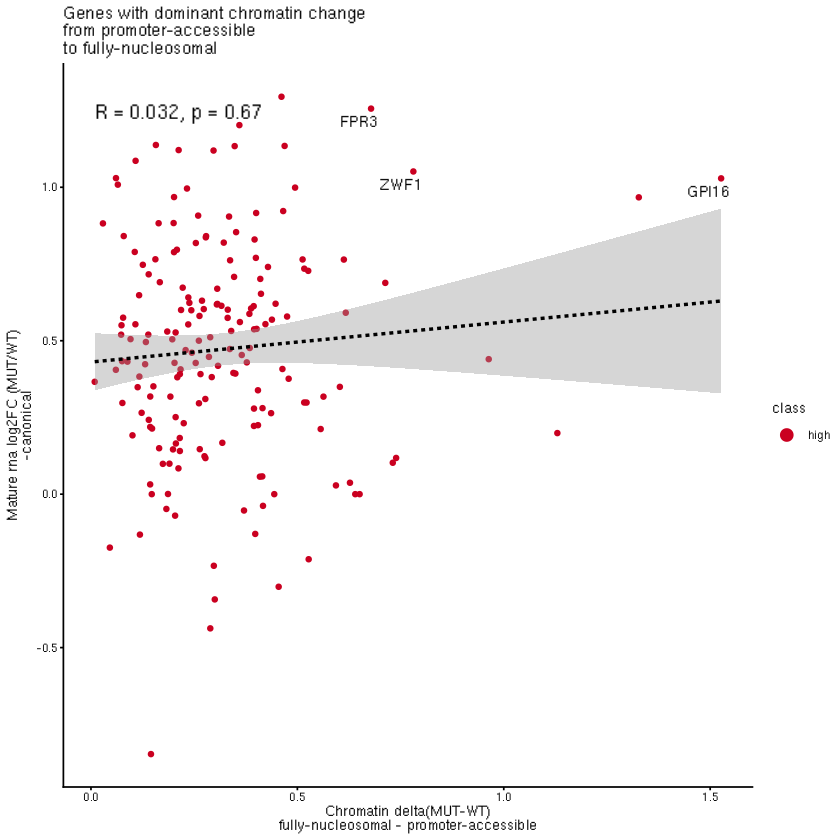

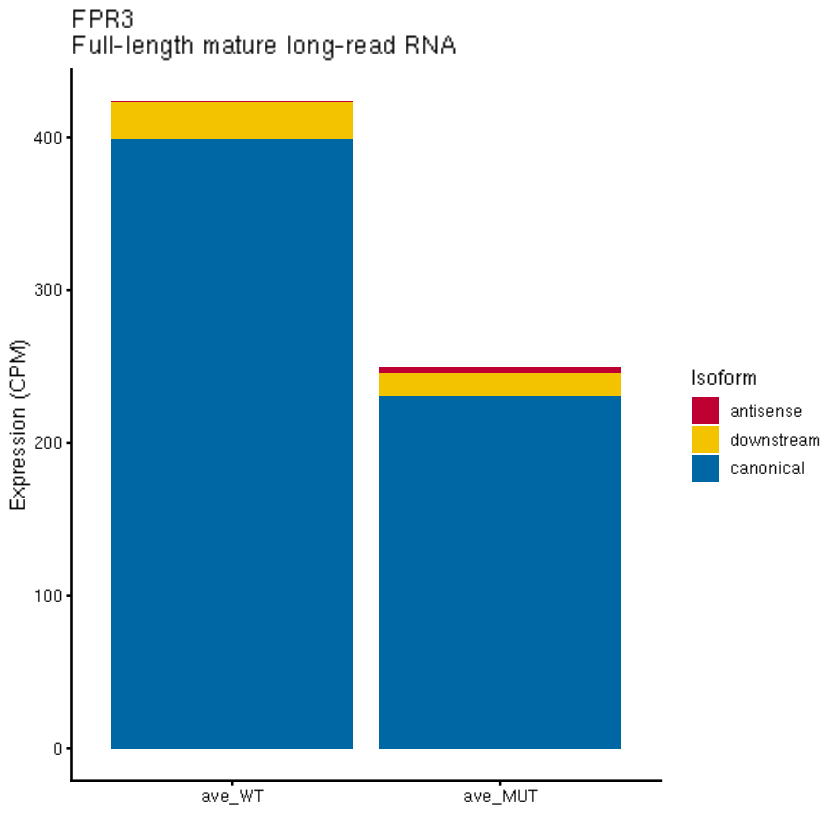

In [825]:
down_state = c('promoter-accessible')
up_state = c('fully-nucleosomal')
WT_state = paste0('WT_mean_', down_state)
MUT_state = paste0('MUT_mean_', up_state)

candidates <- df %>%
    filter(
        if_all(all_of(WT_state),  ~ .x > WT_usage),
        if_all(all_of(MUT_state),  ~ .x > MUT_usage),
        if_all(all_of(down_state), ~ .x < 0),
        if_all(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = -lfc_canonical,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'high')

top_3<- candidates %>% head(n = 10) %>% arrange(lfc_canonical) %>% head(3)
top_3

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_point(aes(color = class), size = 1) +
    labs(x = 'Chromatin delta(MUT-WT)\nfully-nucleosomal - promoter-accessible', 
         y = 'Mature rna log2FC (MUT/WT)\n-canonical',
         title = 'Genes with dominant chromatin change\nfrom promoter-accessible\nto fully-nucleosomal') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    theme_classic(base_size=8) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = top_3,
        aes(label = geneid),
        size = 3, max.overlaps = 12
    ) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave('../figures/Supp_correlation_chromain_isoform_promoter_accessible_down_fully-nucleosomal_up.pdf', width = 4, height = 3)

plot_expr_telo(tpm, "FPR3")
ggsave('../figures/Supp_FPR3_cpm.pdf', width = 4, height = 3.5)

In [216]:
tpm<- read.table('../data/7_mature_rna_tss_tpm.tsv', header=T, sep="\t", row.names=1, check.names = FALSE)
tpm<- read.table('../data/7_mature_rna_tss_tpm.tsv', header=T, sep="\t", row.names=1, check.names = FALSE)